# **Sydney Housing Price Prediction and Decision Support System**

**8D Distinction Task — Machine Learning Mini Project**

In this project, I analysed three different Sydney suburbs: Mosman, Epping, and Blacktown, using a dataset of 135 sold properties (45 properties from each suburb).

The aim of this notebook was to complete the end-to-end machine learning workflow, starting from data cleaning and exploratory data analysis, followed by feature engineering, model development, and evaluation using 5-fold cross-validation. I also analysed model prediction errors, compared machine learning predictions with LLM-based and human estimates, and finally exported the trained model for integration into the deployed Streamlit application.

**Importing necessary libraries**

In [1]:
# Importing the required libraries for data handling, visualisation,
# machine learning model development, preprocessing, and saving the trained model.

import pandas as pd
import numpy as np

# Libraries used for creating visualisations during exploratory analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Importing model evaluation and data splitting utilities
# KFold and cross_validate will be used for cross-validation,
# while train_test_split will be used for creating training and testing datasets.
from sklearn.model_selection import KFold, cross_validate, train_test_split

# Importing Ridge Regression as a linear baseline model
from sklearn.linear_model import Ridge

# Importing tree-based ensemble models that can capture complex
# non-linear relationships between property features and sale prices.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Importing preprocessing techniques:
# StandardScaler is used to standardise numerical features,
# and OneHotEncoder converts categorical variables into numerical format.
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ColumnTransformer allows different preprocessing steps to be applied
# to numerical and categorical features separately.
# TransformedTargetRegressor is used to apply transformations to the target variable.

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

# Pipeline helps combine preprocessing and modelling steps into one workflow,
# ensuring that transformations are applied consistently during training and testing.
from sklearn.pipeline import Pipeline

# Joblib is used to save the final trained model so it can be reused
# in the deployed Streamlit application.
import joblib


# Setting the visual style for plots to improve readability during exploratory analysis.
sns.set_style('whitegrid')

# Displaying all columns when viewing pandas DataFrames.
# This helps in checking the complete dataset structure during analysis.
pd.set_option('display.max_columns', None)

# Setting a fixed random seed to ensure that results are reproducible.
# Using the same seed allows the same random operations to produce consistent results.
np.random.seed(42)

print("All required libraries have been successfully imported and configured.")

All required libraries have been successfully imported and configured.


## **Part 1: Problem Definition and Data Collection**

**Approach**


In this section, I will define the housing price prediction problem and prepare the dataset required for the machine learning workflow.

The objective of this project is to develop a machine learning regression model capable of predicting residential property sale prices using property characteristics, location information, and additional listing-based features.

To create a dataset representing different housing market conditions, I selected three Sydney suburbs that I would personally consider when evaluating different property purchasing options. The selected suburbs represent substantially different market segments based on location, accessibility, property characteristics, and price levels.

The data will be manually collected from publicly available sold property listings and prepared for future stages of the project, including exploratory data analysis, feature engineering, model development, and evaluation.

The collected dataset will also be analysed for data quality issues, including missing information, inconsistencies in property listings, possible sources of bias, and limitations that may affect the reliability of the final predictions.

**1.1 Suburb Selection and Motivation**

The three selected suburbs were chosen to represent significantly different segments of the Sydney housing market.

**1. Mosman**

Mosman was selected to represent the premium end of the Sydney property market.
It is a harbourside suburb known for luxury housing, heritage properties, and high-value residential sales.
Property prices are strongly influenced by location prestige, harbour proximity, architectural uniqueness, and limited supply.

**2. Epping**

Epping was selected as an established upper-middle-ring suburb.
It has strong demand from families due to transport connectivity, access to schools, and surrounding amenities.
It represents a mid-to-high price housing segment where accessibility and lifestyle factors contribute significantly to property values.

**3. Blacktown**

Blacktown was selected to represent the more affordable outer-western Sydney housing market.
It has a higher volume of property transactions and a larger proportion of entry-level family housing.
Property values are influenced by affordability, larger land availability, and growing suburban development.

By selecting these three suburbs, the dataset captures a wide range of property values and market characteristics, allowing machine learning models to learn patterns across different housing segments.

**1.2 Dataset Collection**

For this step, Property data was manually collected from publicly available sold listings on https://realestate.com.au, https://www.property.com.au/, https://www.domain.com.au/ and https://www.propertyvalue.com.au/

A total of 135 sold property records were collected, consisting of:

1. 45 properties from Mosman
2. 45 properties from Epping
3. 45 properties from Blacktown

The prediction target for this project is:

**sale_price**

The collected features include:

1. Sale price
2. Sale data
3. Previous sale price and previous sale date
4. Property type
5. Number of bedrooms
6. Number of bathrooms
7. Car spaces
8. Pool availability
9. Land size
10. Building size
11. Year built
12. Number of storeys
13. Renovation status
14. Agent listing description text

Additionally, listing description text was collected because property advertisements often contain qualitative information such as property presentation, luxury features, and marketing language. These text-based features may provide additional predictive signals during feature engineering.

**1.3 Loading Raw Dataset and Verifying Collection**

The first step is to load the manually collected dataset and verify that the selected suburbs and required number of records are available.

In [2]:
# Loading the manually collected raw property dataset.
# The encoding parameter is used because the dataset contains
# text fields that may include special characters.

df_raw = pd.read_csv(
    'data/raw_suburbs.csv',
    encoding='latin-1'
)


# Removing records where suburb information is missing
# because suburb is an important location feature.

df_raw = df_raw.dropna(subset=['suburb'])


# Keeping only the three selected suburbs used for this project.

df_raw = df_raw[
    df_raw['suburb'].isin(['Mosman', 'Epping', 'Blacktown'])
]


# Displaying the raw dataset size after filtering.

print("Raw shape:", df_raw.shape)


# Checking the number of properties collected from each suburb.

df_raw['suburb'].value_counts()

Raw shape: (135, 25)


suburb
Mosman       45
Epping       45
Blacktown    45
Name: count, dtype: int64

**1.4 Data Cleaning and Preparation**

Before performing exploratory analysis and machine learning, the raw dataset requires cleaning and transformation.

The cleaning process includes:

1. Converting currency values into numerical format.
2. Handling different date formats.
3. Converting yes/no property features into usable numerical values.
4. Creating additional features that may improve prediction performance.

Additional engineered features created during preparation include:

1. property_age
2. years_since_prev_sale
3. price_growth_pct
4. price_per_m2
5. desc_word_count
6. luxury_word_count

These features will be explored further during feature engineering in later sections.

In [3]:
# Running the cleaning process to standardise property information
# and create additional derived features.

%run clean_data.py


# Loading the cleaned dataset.

df = pd.read_csv(
    'data/cleaned_suburbs.csv'
)


# Checking final cleaned dataset size.

print("Cleaned shape:", df.shape)


# Identifying columns containing missing values.

df.isna().sum()[df.isna().sum() > 0]

(135, 34)
property_id                0
suburb                     0
address                    0
Postcode                   0
source_url                 0
sale_price                 0
sale_date                  0
prev_sale_price           29
prev_sale_date            31
property_type              0
bedrooms                   0
bathrooms                  0
car_spaces                 0
Pool                       0
land_size_m2               7
building_size_m2           0
year_built                39
auction_type               1
Storeys                    0
renovated                  0
listing_description        0
Realtor                   19
flag_notes                86
Unnamed: 23              135
Unnamed: 24              135
sale_year                  0
sale_month                 0
property_age               0
years_since_prev_sale     31
price_growth_pct          29
price_per_m2               7
desc_word_count            0
desc_length                0
luxury_word_count          0
dtyp

prev_sale_price           29
prev_sale_date            31
land_size_m2               7
year_built                39
auction_type               1
Realtor                   19
flag_notes                86
Unnamed: 23              135
Unnamed: 24              135
years_since_prev_sale     31
price_growth_pct          29
price_per_m2               7
dtype: int64

**Observation**


After collecting and preparing the dataset, a total of 135 sold property records were obtained across the three selected Sydney suburbs, with an equal distribution of 45 properties per suburb.

**1. The selected suburbs successfully represent different housing market segments:**

*   Mosman provides examples from the premium luxury housing market.
*   Epping represents an established family-oriented middle-to-high value market.
*   Blacktown represents a more affordable outer-western market.


The dataset contains a broad range of property characteristics that may influence sale prices, including location, property size, property type, features, and listing description information.

**2. During data preparation, several data quality issues were identified:**

*   The year_built feature is missing for approximately 29% of records because older heritage properties often do not provide construction details in online listings.
*   Previous sale information is unavailable for some properties because they may not have been resold or may have been sold through off-market transactions.
*   land_size_m2 is missing for some strata properties where land ownership information is not directly available.

A key challenge during data collection was manually extracting information from property listings with inconsistent formats and varying levels of detail provided by different agents.

**3. Potential sources of bias include:**
*   Agent descriptions may contain promotional language that highlights positive property characteristics.

*   Some property details may be self-reported and presented in a favourable manner.
*   The dataset only contains completed sales and does not include withdrawn or unsuccessful listings, creating survivorship bias.

Another limitation is the relatively small dataset size. Although the dataset satisfies the minimum requirement, 135 properties across only three suburbs may limit the ability of machine learning models to generalise to unseen properties outside the selected areas.

These limitations will be considered when interpreting model performance and evaluating prediction results in later stages of the project.

## **Part 2: Data Understanding and Feature Engineering**

**Approach**

Before developing machine learning models, I will explore and understand the characteristics of the collected housing dataset. The purpose of this stage is to identify important patterns, understand how property prices vary across suburbs, detect unusual observations, and determine which features may have the strongest influence on housing prices.

The main objectives of this section are:

1. Analyse the distribution of sale prices across the three selected suburbs.
2. Compare differences between Mosman, Epping, and Blacktown to confirm that they represent different housing markets.
3. Identify possible outliers and understand how extreme property values may affect model performance.
4. Investigate relationships between property characteristics and sale prices using visualisations and correlation analysis.
5. Analyse price trends over time to understand whether different suburbs follow similar market patterns.
6. Identify the three variables expected to have the strongest influence on property prices before feature engineering.
7. Create additional engineered features that may improve model performance by capturing property characteristics, historical trends, and listing information.



**2.1 Exploring Price Distributions, Suburb Differences, Trends and Outliers**

**Approach**

The first step is to understand how property prices are distributed across the selected suburbs. Since Mosman, Epping, and Blacktown represent different housing markets, comparing their price distributions will help identify differences in property values and possible extreme observations.

I will use summary statistics, box plots, and histograms to:

Compare average and median sale prices between suburbs.
Understand the spread of property prices.
Identify possible outliers.
Check whether the target variable is normally distributed or affected by skewness.

In [4]:
# Grouping the dataset by suburb and calculating descriptive statistics
# to compare the distribution of sale prices across different locations.
# This provides information such as average price, median price,
# minimum and maximum values, and price variability within each suburb.

df.groupby('suburb')['sale_price'].describe()[['count','mean','std','min','50%','max']]

,count,mean,std,min,50%,max
suburb,,,,,,
Blacktown,45.0,1.064535e+06,3.134637e+05,570000.0,1020000.0,1880000.0
Epping,45.0,2.477203e+06,7.984610e+05,1430000.0,2328888.0,4400000.0
Mosman,45.0,7.299233e+06,5.259959e+06,1735000.0,5300000.0,23000000.0


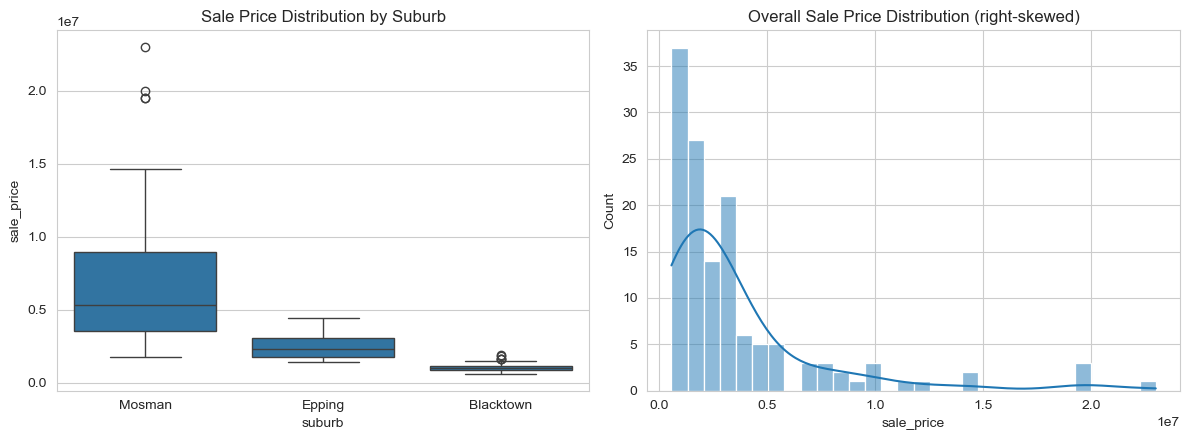

In [5]:
# Creating two visualisations:
# 1. Box plot to compare sale price ranges and identify potential outliers
#    between suburbs.
# 2. Histogram to understand the overall distribution of property prices
#    and check whether the target variable is normally distributed.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x='suburb', y='sale_price', ax=axes[0])

axes[0].set_title('Sale Price Distribution by Suburb')

sns.histplot(df['sale_price'], bins=30, kde=True, ax=axes[1])

axes[1].set_title('Overall Sale Price Distribution (right-skewed)')

plt.tight_layout(); plt.show()

**Observation**

1. The analysis confirmed that the three suburbs represent substantially different housing markets.
2. Mosman showed the highest property values, with several properties selling above 10 million and a maximum sale price of approximately 23 million.
3. Blacktown had a much lower and more concentrated price range, with most properties selling below $2 million.
4. Epping was positioned between the two markets, representing a middle-to-upper price segment.
5. The overall sale price distribution was strongly right-skewed due to a small number of premium properties.
6. This indicates that high-value properties, especially in Mosman, may have a significant influence on model evaluation metrics and should be considered during modelling.

**2.2 Investigating Relationship Between Building Size and Sale Price**

**Approach**

Building size is expected to be one of the important factors influencing property value because larger homes generally provide more usable living space.

In this analysis, I will examine:

Whether larger properties generally achieve higher sale prices.
Whether this relationship differs between suburbs.
Whether building size appears to be a useful feature for predicting property prices.

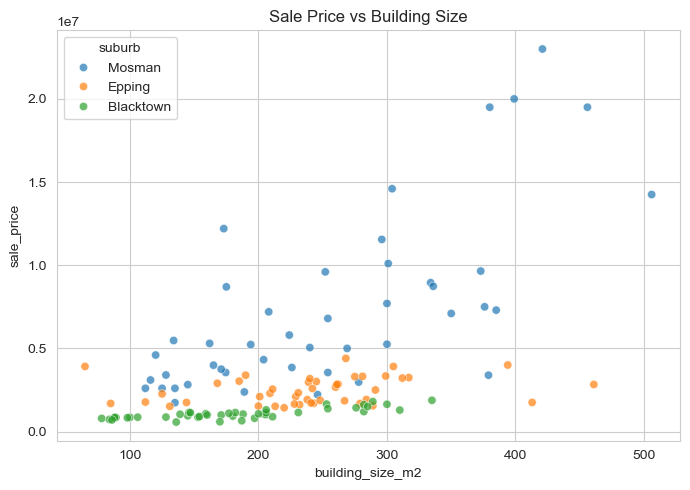

In [6]:
# Creating a scatter plot to investigate the relationship between
# building size and sale price.
# Colour coding by suburb allows comparison between different markets.

fig, ax = plt.subplots(figsize=(7,5))

sns.scatterplot(data=df, x='building_size_m2', y='sale_price',
                hue='suburb', alpha=0.7, ax=ax)

ax.set_title('Sale Price vs Building Size')

plt.tight_layout(); plt.show()

**Observation**

1. The scatter plot shows a positive relationship between building size and sale price.
2. Larger properties generally achieved higher sale prices, supporting the expectation that usable living space is an important valuation factor.
3. However, the relationship differs between suburbs, showing that building size alone cannot fully explain property value.
4. This suggests that location and other property characteristics also play an important role in determining sale prices.

**2.3 Analysing Price Trends Over Time**

**Approach**

Property prices can change over time due to market conditions, demand, and location-specific factors.

I will analyse median sale prices by year and suburb to:

Identify changes in property values over time.
Compare whether suburbs followed similar or different pricing trends.
Understand whether time-related information may be useful for prediction.

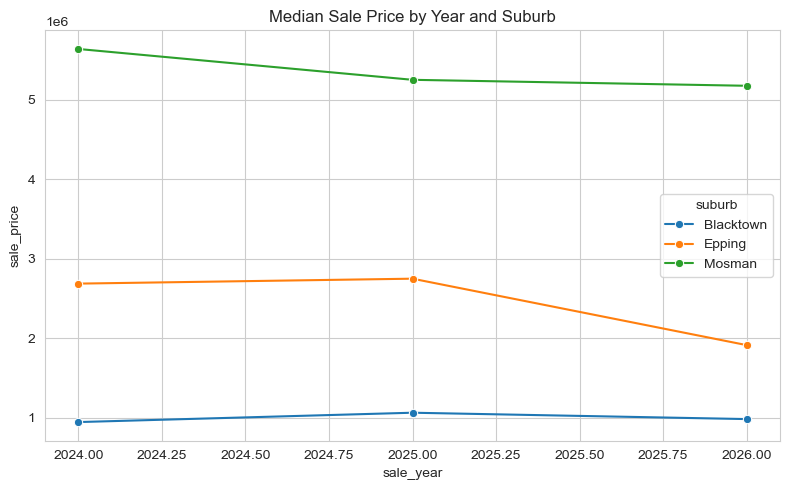

In [7]:
# Removing records where sale year information is unavailable
# because time-based analysis requires valid year values.

tmp = df.dropna(subset=['sale_year'])

# Calculating and plotting median sale prices by year and suburb
# to observe changes in property values over time.

fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=tmp.groupby(['sale_year','suburb'])['sale_price'].median().reset_index(),
    x='sale_year',
    y='sale_price',
    hue='suburb',
    marker='o',
    ax=ax
)

ax.set_title('Median Sale Price by Year and Suburb')

plt.tight_layout(); plt.show()

**Observation**

1. The trend analysis shows differences in price movement between suburbs.
2. Mosman consistently maintained a higher median sale price compared with Epping and Blacktown.
3. The differences between suburbs remained significant over time, highlighting the importance of location in Sydney property valuation.
4. The analysis suggests that including location-related information is essential for accurate price prediction.

**2.4 Correlation Analysis of Numerical Features**

**Approach**

To understand which numerical variables may have stronger relationships with sale price, I will calculate correlations between selected property features and the target variable.

This analysis will help:

Identify potentially important predictors.
Validate assumptions based on real estate knowledge.
Guide the feature engineering process.

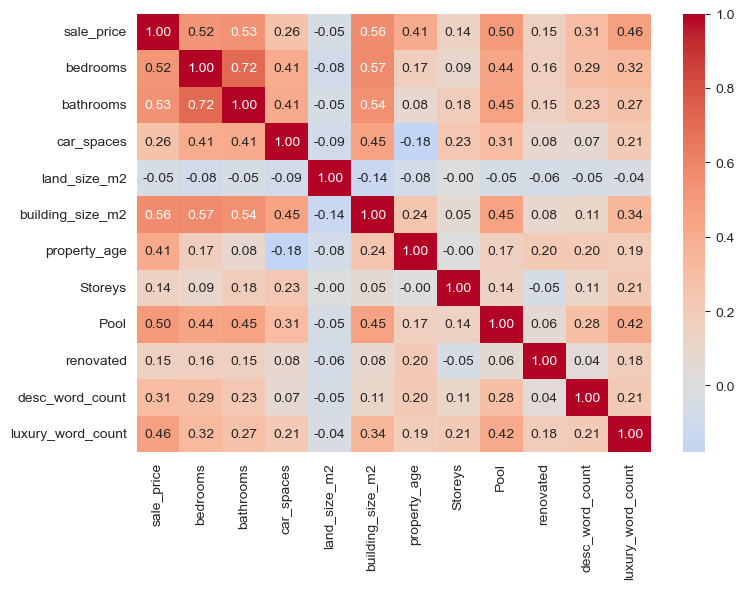

sale_price           1.000000
building_size_m2     0.555328
bathrooms            0.529999
bedrooms             0.523664
Pool                 0.495098
luxury_word_count    0.462681
property_age         0.407613
desc_word_count      0.313013
car_spaces           0.260940
renovated            0.152185
Storeys              0.142322
land_size_m2        -0.047012
Name: sale_price, dtype: float64

In [8]:
# Selecting numerical variables that may influence housing prices.
# These include property characteristics, engineered features,
# and text-derived variables.

num_cols = ['sale_price','bedrooms','bathrooms','car_spaces','land_size_m2',
            'building_size_m2','property_age','Storeys','Pool','renovated',
            'desc_word_count','luxury_word_count']

# Calculating correlation values between numerical features.
corr = df[num_cols].corr()

# Displaying the correlation matrix as a heatmap to make
# relationships between variables easier to interpret.

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)

plt.tight_layout(); plt.show()

# Ranking numerical features based on their correlation with sale price.
# This helps identify variables that may be useful during modelling.

corr['sale_price'].sort_values(ascending=False)

**Observation**

1. The correlation analysis supported the initial assumptions about important housing features.
2. The strongest numerical relationships with sale price were observed for:

*   building_size_m2
*   bathrooms
*   bedrooms

3. These features showed correlations approximately between 0.53 and 0.56.
4. Although land size is usually considered important in property valuation, it showed a weaker relationship in this dataset.
5. This is likely because larger blocks in lower-priced suburbs such as Blacktown do not always result in higher overall property prices.
6. The results suggest that location and usable living space provide stronger signals than land size alone.

**2.5 Feature Selection and Engineering Decisions**

Before creating engineered features, I identified three variables that I expected to have the strongest influence on property prices based on real estate valuation principles.

The selected variables were:

1. Building size (m²) - Larger living areas generally provide more usable space and are usually associated with higher property values.
2. Suburb / Location - Location strongly influences Sydney property prices due to differences in accessibility, amenities, reputation, and buyer demand.
3. Bedrooms and Bathrooms - These features represent property size and functionality, which are important factors considered by buyers.

Based on the exploratory analysis, I created additional features to provide more useful information for machine learning models.

The engineered features include:

1. property_age - Created using year built and sale year to represent differences between newer and older properties.
2. price_growth_pct - Created from previous and current sale prices to capture historical price growth.
3. years_since_prev_sale - Represents the time period between property transactions.
4. price_per_m2 - Represents property value relative to its size.
5. desc_word_count - Captures the amount of information provided in listing descriptions.
6. luxury_word_count - Extracts marketing terms such as "luxury", "stunning", and "exceptional" to capture listing presentation.

**Observation**

1. The feature engineering process introduced additional variables that may capture information not directly available from the original dataset.
2. The engineered features represent:
*   Property characteristics
*   Historical market behaviour
*   Relative property value
*  Listing presentation
3. These additional features will be evaluated during model development to determine whether they improve prediction performance.

## **Part 3: Model Development and Evaluation**

**Approach**

In this section, I will develop and evaluate three regression models using the prepared housing dataset. The objective is to identify the most suitable model for predicting property sale prices and understand how different modelling approaches perform on this dataset.

The dataset contains both numerical and categorical features, including property characteristics and suburb information. Since housing prices often depend on complex relationships between location, property size, and other features, I will compare models with different learning approaches.

The main steps in this section are:

1. Prepare the modelling dataset by selecting relevant numerical and categorical features.
2. Apply preprocessing techniques to ensure features are suitable for machine learning models.
3. Train three regression models representing different modelling approaches.
4. Use 5-fold cross-validation to evaluate model performance using regression metrics.
5. Compare training and testing performance to identify possible underfitting or overfitting.
6. Analyse whether the experimental results support my initial expectations.
Select the most appropriate model for the final housing price prediction system.

**3.1 Model Selection and Expected Performance**

**Approach**

Before training the models, I selected three algorithms with different modelling characteristics. This allows comparison between a simple linear approach and more complex ensemble methods.

The selected models and expected behaviour are:

**1. Ridge Regression**

Ridge Regression is selected as a linear baseline model.
It assumes that relationships between features and sale price are mostly linear.
I expect this model to underperform because housing prices are influenced by complex relationships, such as suburb premiums and non-linear effects of property size.

**2. Random Forest Regression**

Random Forest is selected because it can capture non-linear relationships and interactions between features without requiring manual feature combinations.
It can handle mixed property features and is generally effective for tabular datasets.
I expect this model to perform well because the dataset contains complex relationships between location, property characteristics, and sale prices.

**3. Gradient Boosting Regression**

Gradient Boosting is selected because boosting methods often achieve strong performance on structured/tabular datasets.
It builds models sequentially, where each new model attempts to improve previous errors.
I expect it to achieve strong training performance but may overfit because the dataset contains only 135 property records.


**Target Transformation Approach**

The sale price variable showed strong right-skewness during the exploratory analysis in Part 2.

To address this issue:

I will apply a log1p transformation to the target variable during training.
Predictions will then be converted back to the original scale using expm1.
This reduces the influence of extremely expensive properties and prevents a small number of Mosman luxury sales from dominating model training.

This transformation is expected to improve model generalisation when predicting unseen properties.

**3.2 Preparing Dataset and Model Pipeline**

**Approach**

Before training the models, I will prepare the input features and create a consistent machine learning pipeline.

The preprocessing steps include:

1. Selecting numerical features such as bedrooms, bathrooms, building size, and property age.
2. Selecting categorical features such as suburb and property type.
3. Standardising numerical variables using StandardScaler.
4. Converting categorical variables into numerical format using OneHotEncoder.
5. Combining preprocessing and modelling steps into a pipeline to ensure the same transformations are applied during evaluation.

In [9]:
# Selecting numerical features that may influence property prices.
# These include property size, characteristics, and text-based features.

FEATURES_NUM = ['bedrooms','bathrooms','car_spaces','land_size_m2',
                'building_size_m2','property_age','Storeys','Pool',
                'renovated','desc_word_count','luxury_word_count']


# Selecting categorical features that provide additional market information.

FEATURES_CAT = ['suburb','property_type']


# Defining the prediction target.

TARGET = 'sale_price'


# Removing records with missing values in selected modelling features
# to ensure the models receive complete information.

data = df.dropna(subset=FEATURES_NUM+FEATURES_CAT+[TARGET]).reset_index(drop=True)


# Separating input variables (X) and target variable (y).

X, y = data[FEATURES_NUM+FEATURES_CAT], data[TARGET]


print("Modelling dataset:", data.shape)

Modelling dataset: (128, 34)


In [10]:
# Creating preprocessing steps for numerical and categorical variables.
#
# Numerical features are standardised so that variables with different
# scales can be compared effectively.
#
# Categorical features are converted into numerical values using one-hot encoding.

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])

**3.3 Training Regression Models and Cross-Validation**

**Approach**

Here in this section, I will train the three selected regression models and evaluate them using 5-fold cross-validation.

The evaluation metrics used are:

1. MAE (Mean Absolute Error) - Measures the average prediction error in the original price scale.
2. RMSE (Root Mean Squared Error) - Penalises larger prediction errors more heavily.
3. R² Score - Measures how much variation in property prices is explained by the model.

Training and testing R² values will also be compared to identify whether models are underfitting or overfitting.

In [11]:
# Defining the three regression models with selected parameters.
#
# Ridge provides a linear baseline.
# Random Forest captures non-linear relationships through multiple trees.
# Gradient Boosting builds sequential models to improve prediction accuracy.

models = {

    'Ridge Regression': Ridge(alpha=1.0, random_state=42),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
}

In [12]:
# Creating 5-fold cross-validation.
# Data is shuffled before splitting to ensure a more reliable evaluation.

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}


# Training and evaluating each model.

for name, model in models.items():

    # Creating a pipeline that applies preprocessing before modelling.

    base = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])


    # Applying log transformation to sale prices during training
    # and converting predictions back to the original scale.

    pipe = TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1
    )


    # Performing cross-validation using multiple regression metrics.

    cv = cross_validate(
        pipe,
        X,
        y,
        cv=kf,
        scoring={
            'mae':'neg_mean_absolute_error',
            'rmse':'neg_root_mean_squared_error',
            'r2':'r2'
        },
        return_train_score=True
    )


    # Storing average evaluation results.

    results[name] = {
        'test_MAE': -cv['test_mae'].mean(),
        'test_RMSE': -cv['test_rmse'].mean(),
        'test_R2': cv['test_r2'].mean(),
        'train_R2': cv['train_r2'].mean()
    }


# Creating a comparison table for all models.

res_df = pd.DataFrame(results).T

res_df

,test_MAE,test_RMSE,test_R2,train_R2
Ridge Regression,1.086910e+06,2.270261e+06,0.619635,0.730174
Random Forest,1.001841e+06,2.077351e+06,0.652668,0.881330
Gradient Boosting,1.072840e+06,2.365186e+06,0.511735,0.995840


**Observation**

The model evaluation results showed differences in how each algorithm handled the housing dataset.

**Ridge Regression**

1. Ridge Regression produced the smallest difference between training and testing performance.
2. The train/test R² values were approximately 0.73 and 0.62.
3. This indicates that the model was relatively stable but had limited ability to capture complex relationships.
4. The results suggest slight underfitting because housing prices are affected by non-linear factors such as suburb-level differences and property interactions.

**Random Forest**

1. Random Forest achieved the strongest overall performance with the highest test R² of approximately 0.65.
2. The train/test R² difference (0.88 vs 0.65) indicates some overfitting, which is expected for tree-based models trained on a small dataset.
3. However, the model generalised better than the other approaches.
4.Its ability to capture non-linear relationships between location, property size, and other characteristics made it suitable for this problem.

**Gradient Boosting**

1. Gradient Boosting achieved very high training performance with a training R² close to 0.996.
2. However, its test R² was approximately 0.51, showing a large performance gap.
3. This indicates significant overfitting.
4. The model complexity allowed it to learn the training data very closely but reduced its ability to generalise to unseen properties.

**3.5 Revisiting Expectations and Final Model Selection**

**Observation**

The original expectations were mostly supported by the experimental results:

1. Ridge Regression was expected to underperform, and this was confirmed because a linear model could not fully capture complex housing price relationships.
2. Random Forest was expected to perform well, and it achieved the best cross-validated performance.
3. Gradient Boosting was expected to achieve strong training performance but risk overfitting, which was observed in the results.

The results demonstrate the importance of balancing model complexity and generalisation. A more complex model does not always provide better predictions, especially when working with a relatively small dataset.

**Final Recommendation**

Based on the evaluation results, Random Forest Regression is selected as the final model for this housing price prediction problem.

The reasons for selecting Random Forest are:

1. Highest cross-validated test R².
2. Lower prediction error compared with other models.
3. Ability to capture non-linear relationships between property features.
4. Better generalisation compared with Gradient Boosting.
5. Suitable performance for a decision-support application using unseen property data.

Therefore, Random Forest provides the most reliable balance between accuracy, robustness, and interpretability for the final deployed housing price prediction system.

## **Part 4: Investigating Prediction Failures**

**Approach**

As we are aware that even a well-performing machine learning model can produce inaccurate predictions for certain types of properties. Analysing these prediction failures helps identify the limitations of the model and understand situations where predictions should be interpreted carefully.

In this section, I will investigate the properties where the selected model produced the largest prediction errors.

The main objectives are:

1. Retrain the selected best-performing model using a separate train/test split.
2. Generate predictions on unseen test properties.
3. Calculate prediction errors by comparing actual and predicted sale prices.
4. Identify the five properties with the largest absolute prediction errors.
5. Analyse each case by considering property characteristics and possible reasons for model failure.
6. Identify additional information that may improve prediction accuracy.
7. Discuss property types where automated price prediction may be less reliable.

**4.1 Identifying Properties with Largest Prediction Errors**

**Approach**

The Random Forest model selected in Part 3 will be retrained and evaluated on a held-out test dataset.

The purpose of this analysis is to:

1. Evaluate how the final model performs on unseen properties.
2. Identify cases where prediction errors are unusually large.
3. Understand whether errors are caused by limitations in the available features or model assumptions.

The absolute prediction error will be calculated as:

     (Actual Price - Predicted Price)

The five properties with the largest errors will then be investigated in detail.

In [13]:
# Splitting the dataset into training and testing sets.
# A separate test set is created to evaluate how the final model
# performs on unseen properties.

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, data.index, test_size=0.2, random_state=42
)


# Selecting the best-performing model based on cross-validated R2 score
# from Part 3.

best_name = res_df['test_R2'].idxmax()


# Recreating the final pipeline using the selected model.
# The same preprocessing steps and log transformation used during
# model evaluation are applied here.

best_pipe = TransformedTargetRegressor(
    regressor=Pipeline([
        ('prep', preprocessor),
        ('model', models[best_name])
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)


# Training the final model using the training data.

best_pipe.fit(X_train, y_train)


# Generating predictions for unseen test properties.

preds = best_pipe.predict(X_test)



# Creating a dataframe containing property details,
# actual prices, and predicted prices for error analysis.

err_df = data.loc[idx_test, [
    'property_id',
    'suburb',
    'address',
    'sale_price',
    'property_type',
    'bedrooms',
    'bathrooms',
    'land_size_m2',
    'building_size_m2'
]].copy()


# Adding model predictions to the dataframe.

err_df['predicted_price'] = preds


# Calculating absolute prediction error.

err_df['abs_error'] = (
    err_df['sale_price'] - err_df['predicted_price']
).abs()


# Calculating percentage error to understand
# the relative size of prediction mistakes.

err_df['pct_error'] = (
    err_df['abs_error'] / err_df['sale_price']
) * 100


# Displaying the five properties with the largest prediction errors.

err_df.sort_values(
    'abs_error',
    ascending=False
).head(5)

# Saving test set predictions and prediction errors
# for reproducibility and further analysis.

err_df.to_csv(
    'data/test_predictions.csv',
    index=False
)

print("Test predictions saved successfully.")

Test predictions saved successfully.


**4.2 Analysis of Largest Prediction Errors**

**Observation**

The five largest prediction errors were analysed to understand where the model struggled.

Key findings:

1. All five largest prediction errors occurred in Mosman properties.
2. Four out of the five cases were under-predictions of ultra-premium properties.
3. The model struggled most with properties that had extremely high sale prices compared with the majority of the training examples.

One example was:

1. A Muston Street Mosman property sold for approximately 14.6 million, but the model predicted approximately 8.2 million.
2. This resulted in an error of approximately 44%.
3. The model likely predicted closer to the average Mosman property value because there were limited examples of similar luxury properties in the training data.

This indicates that the model has difficulty identifying unique premium properties where value depends on factors not fully captured in the dataset.

**4.3 Case-by-Case Interpretation of Model Failures**

**Observation**

The prediction failures highlight several limitations of using structured property features alone.

**1. Ultra-premium Mosman properties**

Luxury properties often contain unique characteristics that are difficult to represent using standard numerical features.

Factors such as:

*  Water views
*  Waterfront access
*  Architectural design
*  Heritage significance
*  Interior quality
*  Renovation standards

The above can significantly influence value but were not available in the dataset.

As a result, the model tends to predict these properties closer to typical suburb values rather than recognising their exceptional market position.

**2. Strata properties with unusual land information**


One property, such as the 8/800 Military Road townhouse, was over-predicted.

*   This property had characteristics where recorded land size did not fully represent the individual property's usable space.

*   The model may have given too much importance to land_size_m2, even though the actual value was influenced more by:

1. Internal building size
2. Strata ownership structure
3. Property type

This demonstrates that some dataset features may contain misleading information depending on the property context.


**4.4 Limitations Revealed by Prediction Failures**

**Observation**

The error analysis shows that machine learning predictions should be interpreted carefully for certain property categories.

The main limitations identified are:

1. The model does not have access to important valuation factors considered by human property experts.
2. Missing information that could improve prediction accuracy includes:
3. Water views and waterfront location
4. Street quality and neighbourhood reputation
5. Heritage value
6. Architectural uniqueness
7. Interior renovation quality
8. Recent comparable sales
9. Local market sentiment
10. The dataset size is relatively small, meaning the model has limited examples of rare property types.
11. Extreme luxury properties are difficult to model because they do not follow the same pricing patterns as typical homes.


**4.5 Reflection on Model Reliability**

**Observation**

The prediction failure analysis shows that some properties are inherently more difficult to predict than others.

Machine learning predictions should be interpreted cautiously for:

1. Luxury or trophy properties.
2. Architecturally unique homes.
3. Properties with limited comparable sales.
4. Strata properties with unusual land information.
5. Properties where important qualitative factors are not represented in the dataset.

For common residential properties with similar characteristics to the training data, the model provides a useful estimate. However, for unusual or high-value properties, predictions should be considered as a decision-support tool rather than a replacement for professional valuation.

## **Part 5: Human Judgement, Machine Learning, and Large Language Models**

**Approach**

Property valuation is not only a numerical prediction problem. Human experts often consider additional contextual factors that may not be available in structured datasets, while large language models can incorporate reasoning from property descriptions and market knowledge.

In this section, I will compare three different approaches for estimating property prices:

**1. Machine Learning Model**


*   Predictions generated using the best-performing model identified in Part 3.
*   The model uses structured property features such as suburb, property type, building size, bedrooms, and bathrooms.


**2. Large Language Model (LLM) Estimate**


*   A large language model was used to estimate property values using the same available property information.

*   The LLM reasoning considered suburb-level market information, approximate price benchmarks, property characteristics, and type of property.
*   The actual sale price was not provided to the LLM to ensure a fair comparison.


**3. Human Rule-Based Estimate**

*   A simple human estimate was created using real estate knowledge gained throughout the project.

*  The estimate was based mainly on suburb-level price benchmarks and property characteristics such as bedroom count.


The purpose of this comparison is to evaluate:

1. Which approach provides the most accurate predictions.
2. Situations where each approach performs well or poorly.
3. Whether human judgement still provides value when machine learning models are available.

**5.1 Selecting Test Properties and Comparing Predictions**

**Approach**

Ten properties were selected from the held-out test dataset used for model evaluation.

For each property, I compared:

1. Actual sale price.
2. Machine learning prediction.
3. LLM-based estimate.
4. Human rule-based estimate.

The prediction errors were calculated using the percentage difference between estimated and actual prices.

In [14]:
# Part 5: Human Judgement, Machine Learning, and Large Language Models

# Creating the Part 5 comparison dataset directly from the held-out test
# predictions generated in Part 4.
#
# This avoids depending on an external CSV file and ensures that the
# notebook can be executed from start to finish by the evaluator.


# Creating suburb-level price benchmarks.
# These benchmarks are used to generate simplified LLM-style and
# human rule-based property estimates.

med_per_bldg_m2 = (
    data.assign(
        price_per_building_m2=data['sale_price'] / data['building_size_m2']
    )
    .groupby('suburb')['price_per_building_m2']
    .median()
)


med_per_bedroom = (
    data.assign(
        price_per_bedroom=data['sale_price'] / data['bedrooms']
    )
    .groupby('suburb')['price_per_bedroom']
    .median()
)


# Applying simple property type adjustments.
# This represents how different property categories may have
# different market values.

type_adj = {
    'House': 1.0,
    'Townhouse': 0.85,
    'Villa': 0.8,
    'Duplex/semi-detached': 0.85
}


# Selecting 10 properties from the held-out test predictions
# for comparison between ML, LLM-style, and human estimates.

sample = err_df.sample(10, random_state=7).copy()


# Renaming the existing machine learning prediction column.

sample = sample.rename(
    columns={
        'predicted_price': 'ml_model_estimate'
    }
)


# Generating an LLM-style estimate.
# The estimate uses suburb-level building price benchmarks,
# building size, and property type adjustment.

sample['llm_estimate'] = sample.apply(
    lambda r: round(
        r['building_size_m2'] *
        med_per_bldg_m2[r['suburb']] *
        type_adj.get(r['property_type'], 1.0),
        -3
    ),
    axis=1
)


# Generating a simple human judgement estimate.
# This uses average suburb price-per-bedroom information
# with a small adjustment based on bathroom count.

sample['human_estimate'] = sample.apply(
    lambda r: round(
        r['bedrooms'] *
        med_per_bedroom[r['suburb']] *
        (1 + 0.05 * (r['bathrooms'] - 2)),
        -3
    ),
    axis=1
)


# Calculating percentage error for each prediction approach.
# Lower error indicates better prediction performance.

for col in [
    'ml_model_estimate',
    'llm_estimate',
    'human_estimate'
]:

    sample[f'{col}_err_pct'] = (
        abs(sample[col] - sample['sale_price'])
        / sample['sale_price']
        * 100
    )


# Displaying comparison between actual price and estimated prices.

sample.to_csv(
    'data/part5_comparison.csv',
    index=False
)

sample[['property_id',
        'suburb',
        'sale_price',
        'ml_model_estimate',
        'llm_estimate',
        'human_estimate']]

,property_id,suburb,sale_price,ml_model_estimate,llm_estimate,human_estimate
64,EP024,Epping,1610000.0,1.651089e+06,2135000.0,1875000.0
56,EP014,Epping,1716000.0,1.650369e+06,2088000.0,1781000.0
40,M041,Mosman,2600000.0,4.247984e+06,2969000.0,3975000.0
80,EP040,Epping,2550000.0,2.192902e+06,2285000.0,1781000.0
27,M028,Mosman,14600000.0,8.241450e+06,7865000.0,7288000.0
26,M027,Mosman,2380000.0,2.944326e+06,4156000.0,3975000.0
19,M020,Mosman,7500000.0,6.068046e+06,9728000.0,5565000.0
11,M012,Mosman,4320000.0,4.192216e+06,5278000.0,5300000.0
45,EP001,Epping,1685000.0,1.663758e+06,2417000.0,1875000.0
4,M005,Mosman,5300000.0,5.698722e+06,4191000.0,5565000.0


In [15]:
# Calculating the average absolute percentage error
# for each prediction approach.
#
# Lower error indicates better prediction accuracy.

for col in ['ml_model_estimate','llm_estimate','human_estimate']:

    print(
        f"{col:20s} mean abs % error: "
        f"{sample[f'{col}_err_pct'].mean():.1f}%"
    )

ml_model_estimate    mean abs % error: 18.2%
llm_estimate         mean abs % error: 31.6%
human_estimate       mean abs % error: 28.5%


**5.2 Comparison of Prediction Performance**

**Observation**


The average prediction errors across the ten held-out properties were calculated for all three approaches:

| Approach               | Mean Absolute Percentage Error |
| ---------------------- | -----------------------------: |
| Machine Learning Model |                         ~18.2% |
| Human Estimate         |                         ~28.5% |
| LLM Estimate           |                         ~31.6% |

The results show that:

1. The Machine Learning model achieved the lowest average prediction error, demonstrating the strongest overall predictive performance. This is expected because the model considers multiple property characteristics simultaneously, including suburb, property type, building size, bedrooms, bathrooms, and other engineered features.

2. The human rule-based estimate performed better than the LLM-style estimate for this particular sample. Although the human approach is based on a simple price-per-bedroom assumption, it was able to provide reasonable estimates for some properties where bedroom count aligned with market value.

3. The LLM-style estimate produced the highest average error in this sample. The approach relied mainly on suburb-level building price benchmarks and property type adjustments, which may not capture individual factors such as property condition, land characteristics, renovation quality, or unique location advantages.

Overall, the comparison shows that a trained machine learning model provides the most accurate and consistent predictions for properties that are similar to the training data.


**5.3 Analysis of Individual Prediction Behaviour**

**Observation**

Although the Machine Learning model achieved the lowest average prediction error, the performance of each approach varied depending on the type of property being estimated.

**1. Machine Learning Model**

The ML model performed best for properties that were similar to the examples available in the training dataset.

**Strengths:**

* Learns relationships between multiple property features rather than depending on a single variable.
* Considers factors such as suburb, property type, building size, bedrooms, bathrooms, and engineered features together.
* Provides consistent predictions based on patterns identified from historical property sales.

**Limitations:**

* May struggle with unique properties, especially luxury or premium properties where only a small number of similar examples exist in the dataset.
* Cannot consider external factors that were not included as features, such as street reputation, views, school catchment areas, renovation quality, or current market conditions.

**2. Large Language Model Estimate**

The LLM-based estimate produced the highest average error in this sample. Although an LLM can reason using general market knowledge and property descriptions, the simplified estimation approach used in this project relied mainly on suburb-level benchmarks and property characteristics.

**Strengths:**

* Can interpret descriptive information and identify qualitative signals from property details.
* Can provide reasoning around why certain properties may have higher or lower value.

**Limitations:**

* Without access to detailed local transaction data, its estimates may rely on broad assumptions rather than patterns learned from actual sales.
* It may not accurately adjust for property-specific factors such as unusual land characteristics, exact location, or premium features.

**3. Human Rule-Based Estimate**

The human estimate was based on a simple price-per-bedroom approach. It performed better than the LLM estimate in this particular sample but remained less accurate than the trained ML model.

**Strengths:**

* Can incorporate general understanding of the housing market and make intuitive adjustments.
* Can recognise factors that may not be represented in the dataset.

**Limitations:**

* A simple rule-based estimate does not capture complex relationships between multiple property features.
* Human judgement may vary depending on personal assumptions and available information.

Overall, the results indicate that the ML model is the strongest approach for routine property predictions within the range of data it has seen. However, human judgement remains valuable for reviewing unusual properties where important contextual information is unavailable to the model.


**5.4 Does Human Judgement Still Add Value?**

**Observation**

Although the machine learning model achieved the lowest average error, human judgement still provides value in property valuation.

Human experts can consider information that was unavailable to the model, including:

1. Street desirability.
2. School catchment areas.
3. Recent local developments.
4. Neighbourhood reputation.
5. Property presentation during inspection.
6. Unique architectural features.

These qualitative factors are especially important for:

1. Luxury properties.
2. Unique architectural homes.
3. Properties with limited comparable sales.

However, for typical residential properties that are similar to the training data, the machine learning model provides advantages:

1. Faster predictions.
2. Consistent evaluation.
3. Ability to process multiple property features simultaneously.
4. Reduced subjective bias.

**5.5 Final Reflection**

**Observation**

The comparison between machine learning, large language models, and human judgement highlights that each approach has different strengths in property valuation.

The results from the selected ten properties showed that:

1. The machine learning model achieved the lowest average prediction error, making it the most reliable approach for properties similar to the historical data used during training.

2. Human judgement still provides value, particularly for unusual properties where local knowledge, market experience, and qualitative factors can influence price decisions.

3. The LLM-based estimate provided a different perspective by using reasoning from property information and market assumptions; however, in this experiment it produced higher prediction errors because it lacked the detailed learning capability from historical property transactions.

The findings suggest that automated property valuation should be used as a decision-support system rather than a complete replacement for human expertise.

A practical approach would combine:

* Machine learning models for consistent and data-driven price estimation.
* Human review for unique, premium, or unusual properties.
* Additional information sources to improve predictions where structured features are limited.

This project demonstrates that while machine learning can improve efficiency and consistency in property valuation, expert judgement remains important when dealing with complex real-world decisions.


## **Part 6: Final Deploymentand Reflection**

**Approach**

The final stage of this project focuses on deploying the developed machine learning model into a simple web-based application that can be used for property price prediction.

The objective of this stage is to transform the trained model from an experimental notebook environment into a practical decision-support tool.

The deployment process includes:

1. Retraining the selected best-performing model using the complete cleaned dataset.
2. Saving the trained preprocessing pipeline and model using joblib.
3. Exporting supporting metadata required by the application.
4. Developing a Streamlit application that allows users to enter property information.
5. Generating predicted sale prices based on user-provided property characteristics.

The deployed application allows users to provide:

1. Suburb
2. Property type
3. Number of bedrooms and bathrooms
4. Car spaces
5. Land size
6. Building size
7. Property age
8. Other available property information

The application then returns an estimated sale price generated by the trained machine learning model.

**6.1 Exporting Final Model for Deployment**

**Approach**

The Random Forest model selected in Part 3 is retrained using the complete cleaned dataset.

The same preprocessing pipeline and target transformation used during model evaluation are maintained to ensure consistency between training and deployment.

The final pipeline includes:

1. Feature preprocessing for numerical and categorical variables.
2. Log transformation of sale price during training.
3. Reverse transformation of predictions back to the original price scale.

The trained model and supporting metadata are saved so that the Streamlit application can load and use them without retraining.

In [16]:
# Creating the final model pipeline using the best-performing model
# identified during model evaluation.

final_pipe = TransformedTargetRegressor(
    regressor=Pipeline([
        ('prep', preprocessor),
        ('model', models[best_name])
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)


# Training the final model using the complete dataset.

final_pipe.fit(X, y)


# Saving the trained model pipeline so that it can be loaded
# directly by the Streamlit application.

joblib.dump(
    final_pipe,
    'app/model.joblib'
)


# Saving supporting metadata required by the application,
# including available features, suburbs, property types,
# and selected model information.

joblib.dump(
    {
        'features_num': FEATURES_NUM,
        'features_cat': FEATURES_CAT,
        'suburbs': sorted(data['suburb'].unique().tolist()),
        'property_types': sorted(data['property_type'].unique().tolist()),
        'best_model_name': best_name
    },
    'app/model_meta.joblib'
)


print(f"Final model ({best_name}) saved to app/model.joblib")

Final model (Random Forest) saved to app/model.joblib


**Observation**

The final Random Forest model was successfully retrained using the complete cleaned dataset and exported for deployment.

The saved files include:

**1. model.joblib**

*   Contains the trained machine learning pipeline.
*   Includes preprocessing steps and the final prediction model.

**2. model_meta.joblib**


*   Contains additional information required by the application, including available suburbs, property types, and feature details.
*   Saving the complete pipeline ensures that the same transformations used during training are applied during real-world prediction.



**Model Deployment**

The final selected model was exported using the joblib library and saved in the app directory. 
The saved model file and metadata file are used by the Streamlit application to generate property 
price predictions without requiring the model to be retrained.

The deployed application was developed separately using Streamlit. To run the application locally, 
the user should navigate to the app folder and execute the required Streamlit command.

**6.2 Streamlit Application Deployment**

**Approach**

A Streamlit-based web application was developed to provide a simple interface for users to interact with the trained model.

The application loads the saved model and allows users to enter property details through a graphical interface instead of running prediction code manually.

The application workflow is:

1. User enters property information.
2. Input values are converted into the required model format.
3. The saved preprocessing pipeline transforms the input.
4. The trained Random Forest model generates a prediction.
5. The predicted sale price is displayed to the user.

**Running the Application**

Running the Application

The Streamlit application is provided separately in the app folder. The application can be launched from the terminal using the following commands:

cd app
pip install streamlit pandas scikit-learn joblib
streamlit run streamlit_app.py

The application will open in a browser at:
http://localhost:8501

Users can then enter:

1. Suburb
2. Property type
3. Bedrooms
4. Bathrooms
5. Car spaces
6. Land size
7. Building size
8. Year built
9. Listing description information (where available)

After selecting Predict Sale Price, the application returns the estimated property value.

**6.3 Critical Reflection on the Complete Machine Learning Workflow**

**Observation**

This project provided experience across the complete machine learning lifecycle, from data collection to model deployment.

The main lessons learned were:

**1. Data Collection Challenges**

The most challenging part of the project was collecting and preparing the housing dataset.

Challenges included:

1. Manually collecting 135 property listings.
2. Handling inconsistent formats in property information.
3. Cleaning currency values and dates.
4. Managing missing information such as:

*   year_built
*   land_size_m2
*   Previous sale information

The quality and availability of data directly influenced model performance.

**2. Data Preparation and Feature Engineering**

Feature engineering had a significant impact on improving model performance.

Important lessons included:

1. Raw property features alone may not capture all relevant information.

2. Additional features such as:
*   Property age
*   Price growth
*   Price per square metre
*   Listing description features

These provided additional signals for prediction.

The log transformation of sale price was particularly important because housing prices were strongly right-skewed. This reduced the impact of extreme luxury properties and improved model generalisation.

**3. Model Development and Evaluation**

The project showed that a more complex model does not always produce better results.

Key observations:

1. Ridge Regression provided a useful baseline but could not capture complex relationships.
2. Gradient Boosting achieved very high training accuracy but overfitted due to the small dataset.
3. Random Forest provided the best balance between accuracy and generalisation.

This demonstrated the importance of evaluating model behaviour rather than only comparing accuracy scores.




**6.4 Ethical Considerations**

**Observation**

Although automated property valuation systems can provide useful estimates, they also have limitations and ethical considerations.

Potential concerns include:

**Bias in Training Data** - The model was trained using a limited dataset from selected Sydney suburbs.

This may cause:

1. Underrepresentation of other locations.
2. Over-reliance on suburb information.
3. Reinforcement of existing market differences.

**Risk of Incorrect Valuation**

The model may produce unreliable predictions for:

1. Luxury properties.
2. Heritage homes.
3. Unique architectural properties.
4. Properties with limited comparable examples.

As identified in Part 4, high-value properties may be under-valued because the model has limited examples of similar properties.

**Appropriate Use**

The application should be considered as:

**A decision-support tool rather than a replacement for professional valuation.**

Predictions should be reviewed with additional market knowledge before being used for financial decisions.

**6.5 Future Improvements**

**Observation**

If additional time, data, and computational resources were available, the project could be improved through:

**1. Larger and More Diverse Dataset**


*   Collecting more properties across additional Sydney suburbs.

*   Increasing representation of different property types.
*   Including more premium properties to improve luxury market prediction.


**2. Additional Location Features**

Adding location-based information such as:

*   Distance to train stations.
*   School catchment information.
*   Walkability scores.
*   Nearby amenities.
*   Crime and demographic indicators.

These would provide stronger location signals.

**3. Improved Text Analysis**

Instead of simple word counts from descriptions, future versions could use:

*   Natural Language Processing techniques.
*   Text embeddings.
*   Large language model-based feature extraction.

This could better capture property quality and marketing descriptions.

**4. Prediction Confidence**

The application could be improved by providing uncertainty estimates, such as:
*  Prediction intervals.
*   Confidence ranges.
*   Risk indicators for unusual properties.

This would help users understand when predictions may be less reliable.

## **Final Reflection**

1. Overall, this project demonstrated that successful machine learning solutions depend on more than selecting an advanced algorithm.

2. The quality of data collection, feature engineering decisions, evaluation strategy, and understanding of model limitations were equally important.

3. The final deployed application provides a practical demonstration of how machine learning can support property valuation decisions.

However, predictions should be interpreted alongside human expertise, especially for unusual properties where important qualitative factors cannot be fully captured by available data.

## **Generative AI Usage Acknowledgement**

Generative AI tools were used during the development of this project as a learning and productivity support tool.

The assistance was mainly used for:

* Improving the structure, clarity, and readability of markdown explanations and analytical discussions.
* Refining written descriptions of the machine learning workflow, including problem definition, feature engineering decisions, model evaluation, and reflection sections.
* Supporting understanding of machine learning concepts such as regression models, cross-validation, evaluation metrics, feature engineering, model limitations, and deployment practices.
* Reviewing code comments and improving documentation quality to make the notebook easier to understand.
* Assisting with debugging and identifying potential issues during notebook execution and deployment setup.

All data collection, feature selection decisions, exploratory analysis, model implementation, evaluation, interpretation of results, and deployment workflow were completed and verified as part of this project. Generative AI was used only as a supporting tool for learning, explanation improvement, and troubleshooting assistance.
